<a href="https://colab.research.google.com/github/aodm26/gpt-oss/blob/main/ModelC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GPT-OSS-20B Sentiment Analysis — Speed-Optimised for T4

**Dataset:** `test_split_2.xlsx` — 484 financial headlines (pre-labelled)  
**Labels:** `positive` / `negative` / `neutral` (text, lowercase)  
**Label split:** neutral=288 · positive=136 · negative=60

### Speed decisions for T4 (14.5 GB VRAM)
| Setting | Value | Reason |
|---|---|---|
| `load_in_4bit` | `True` | ~4× less VRAM for weights |
| `max_seq_length` | `1024` | Halves KV-cache pre-allocation vs 2048 |
| `reasoning_effort` | `'low'` | Short think trace; `high` = 167 s/item |
| `max_new_tokens` | `96` | Label word + 1-sentence reason fits easily |
| `do_sample` | `False` | Greedy decode — no sampling overhead |
| Batch size | `1` | Batching causes KV-cache OOM on T4 |
| Prompt | Forces single label word on last line | Zero-ambiguity parsing |


## 1 · Install Dependencies

In [1]:

import os, importlib.util
!pip install --upgrade -qqq uv
if importlib.util.find_spec("torch") is None or "COLAB_" in "".join(os.environ.keys()):
    try: import numpy, PIL; _numpy = f"numpy=={numpy.__version__}"; _pil = f"pillow=={PIL.__version__}"
    except: _numpy = "numpy"; _pil = "pillow"
    !uv pip install -qqq \
        "torch>=2.8.0" "triton>=3.4.0" {_numpy} {_pil} torchvision bitsandbytes "transformers==4.56.2" \
        "unsloth_zoo[base] @ git+https://github.com/unslothai/unsloth-zoo" \
        "unsloth[base] @ git+https://github.com/unslothai/unsloth" \
        git+https://github.com/triton-lang/triton.git@0add68262ab0a2e33b84524346cb27cbb2787356#subdirectory=python/triton_kernels
elif importlib.util.find_spec("unsloth") is None:
    !uv pip install -qqq unsloth
!uv pip install --upgrade --no-deps transformers==4.56.2 tokenizers trl==0.22.2 unsloth unsloth_zoo


Using Python 3.12.12 environment at: /usr
Resolved 5 packages in 121ms
Checked 5 packages in 0.45ms


## 2 · Load Model (4-bit, T4-safe)

In [2]:
from unsloth import FastLanguageModel
import torch

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = "unsloth/gpt-oss-20b-unsloth-bnb-4bit",  # 4-bit — fits T4
    dtype          = None,
    max_seq_length = 256,   # small = less KV-cache VRAM
    load_in_4bit   = True,
    full_finetuning= False,
)
FastLanguageModel.for_inference(model)   # enables optimised inference kernels
print("✓ Model ready.")


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.3.4: Fast Gpt_Oss patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for gpt_oss won't work! Using float32.


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

✓ Model ready.


## 3 · Load Dataset

In [3]:
import pandas as pd

df = pd.read_csv('/content/test_split.csv')

# Normalise labels to Title case so they match parse_label() output
df['sentiment'] = df['sentiment'].str.strip().str.capitalize()

headlines_list  = df['headline'].tolist()
expected_labels = df['sentiment'].tolist()
n = len(headlines_list)

print(f"Loaded {n} headlines.")
print("Label distribution:")
print(df['sentiment'].value_counts().to_string())
print(f"\nSample headline: {headlines_list[0]}")
print(f"Expected label : {expected_labels[0]}")



Loaded 402 headlines.
Label distribution:
sentiment
Neutral     134
Negative    134
Positive    134

Sample headline: In a note to clients published, the Dutch broker described the company's third quarter results as ` soft', although it also noted that Elcoteq retained its guidance, dealers said.
Expected label : Neutral


In [4]:
# ── Configuration ────────────────────────────────────────────────────────────
HEADLINE_COL = 'headline'
LABEL_COL    = 'sentiment'   # numeric: 0=Positive, 1=Negative, 2=Neutral
RANDOM_STATE = 42            # change for a different random draw
N_SAMPLES    = 80

# ── Numeric → text label mapping ──────────────────────────────────────────────
LABEL_MAP = {0: 'Positive', 1: 'Negative', 2: 'Neutral'}

# ── Random sample ─────────────────────────────────────────────────────────────
sample_df = df.sample(n=N_SAMPLES, random_state=RANDOM_STATE).reset_index(drop=True)
headlines_list = sample_df[HEADLINE_COL].tolist()

expected_labels = sample_df[LABEL_COL].tolist()

print(f'Randomly sampled {len(headlines_list)} headlines (random_state={RANDOM_STATE}).')
print(f'Expected label distribution:')
import collections
print(dict(collections.Counter(expected_labels)))
print('\nFirst 3 headlines:')
for i, h in enumerate(headlines_list[:3]):
    print(f'  {i+1}. [{expected_labels[i]}] {h[:90]}...')

# ── Save sample to CSV ───────────────────────────────────────────────────────
sample_df.to_csv("/content/random80.csv", index=False, encoding="utf-8")

print(f"Saved sampled dataset to: /content/random80.csv")


Randomly sampled 80 headlines (random_state=42).
Expected label distribution:
{'Negative': 29, 'Neutral': 23, 'Positive': 28}

First 3 headlines:
  1. [Negative] The company's EBITDA dropped 13.7% year-over-year, reflecting subdued pricing and lower vo...
  2. [Neutral] Finland-based international machinery rental company Ramirent Plc (OMX Helsinki: RMR 1V) r...
  3. [Neutral] The Group brand portfolio includes the leading brand in the industry, Rapala, and other gl...
Saved sampled dataset to: /content/random80.csv


## 4 · Label Parser

Extracts the final sentiment word from model output.  
Two-pass: first looks for an explicit `Final sentiment label:` line, then falls back to the last valid label word found anywhere in the response.


In [12]:
import re

VALID_LABELS = {"Positive", "Negative", "Neutral"}

def parse_reasoning_and_label(text: str):
    if not text:
        return "", "Unknown"

    clean = text.replace("\xa0", " ").replace("**", "").replace("*", "").strip()

    reasoning = ""
    label = "Unknown"

    lines = [l.strip() for l in clean.splitlines() if l.strip()]

    # First pass: look for explicit "Reasoning: ..." and "Label: ..." lines
    temp_reasoning_candidate = ""
    temp_label_candidate = "Unknown"

    for line in lines:
        m_reason = re.match(r'(?i)^reasoning\s*:\s*(.+)$', line)
        if m_reason:
            temp_reasoning_candidate = m_reason.group(1).strip()
            # This ensures we get the *last* explicit reasoning if multiple are present

        m_label = re.match(r'(?i)^label\s*:\s*(positive|negative|neutral)\s*$', line)
        if m_label:
            temp_label_candidate = m_label.group(1).capitalize()
            # This ensures we get the *last* explicit label if multiple are present

    if temp_label_candidate != "Unknown":
        label = temp_label_candidate
        reasoning = temp_reasoning_candidate
    else:
        # If no explicit "Label:" was found, try other fallbacks for the label.
        # Reasoning will remain empty if not found explicitly in this case.

        # Fallback 1: Label appears alone on the last non-empty line
        if lines:
            last_line = lines[-1].strip().capitalize()
            if last_line in VALID_LABELS:
                label = last_line
                reasoning = temp_reasoning_candidate # Use explicit reasoning if found, else empty

        # Fallback 2: Search for any valid label word in the entire clean text,
        # preferring the one closest to the end if multiple are present.
        if label == "Unknown":
            found_labels_with_indices = []
            for valid_lbl_word in VALID_LABELS:
                # Find all occurrences of the label word (case-insensitive, whole word)
                for match in re.finditer(r'\b' + re.escape(valid_lbl_word) + r'\b', clean, re.IGNORECASE):
                    found_labels_with_indices.append((match.start(), valid_lbl_word.capitalize()))

            if found_labels_with_indices:
                # Sort by index to get the last occurring label word
                found_labels_with_indices.sort(key=lambda x: x[0])
                label = found_labels_with_indices[-1][1]
                reasoning = temp_reasoning_candidate # Use explicit reasoning if found, else empty

    return reasoning, label

## 5 · Run Inference

Single-item loop with all T4 speed levers applied.  
`reasoning_effort='low'` keeps the internal think trace short without sacrificing accuracy.


In [16]:
import time
import textwrap
import torch

SYSTEM_PROMPT = """
You are a financial news sentiment classifier.
Classify the headline as Positive, Negative, or Neutral.
Output exactly two lines, and nothing else. Do not explain, repeat the headline, or output any part of this prompt.

Reasoning: maximum 10 words.
Label: Positive, Negative, or Neutral.
""".strip()

BATCH_SIZE = 8
DEBUG = True

device = next(model.parameters()).device

# Safer pad token handling for generation
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id

results = []
start = time.time()
n = len(headlines_list)

for batch_start in range(0, n, BATCH_SIZE):
    batch_end = min(batch_start + BATCH_SIZE, n)

    batch_headlines = headlines_list[batch_start:batch_end]
    batch_expected = expected_labels[batch_start:batch_end]

    batch_text = [
        f"{SYSTEM_PROMPT}\n\nHeadline: {headline}"
        for headline in batch_headlines
    ]

    inputs = tokenizer(
        batch_text,
        return_tensors="pt",
        padding=True,
        truncation=True,
    ).to(device)

    with torch.inference_mode():
        out_ids = model.generate(
            **inputs,
            max_new_tokens=96, # Increased to allow full output as per initial notebook config
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            use_cache=True,
        )

    input_lens = inputs["attention_mask"].sum(dim=1).tolist()

    batch_results = []

    for j, (headline, exp, input_len) in enumerate(
        zip(batch_headlines, batch_expected, input_lens)
    ):
        gen_ids = out_ids[j][input_len:]
        response = tokenizer.decode(gen_ids, skip_special_tokens=True).strip()
        # response = normalize_text(response)
        reasoning, pred = parse_reasoning_and_label(response)
        correct = str(pred) == str(exp)

        idx = batch_start + j + 1

        item = {
            "index": idx,
            "headline": headline,
            "expected": exp,
            "predicted": pred,
            "correct": correct,
            "reasoning": reasoning,
            "raw_response": response,
        }
        results.append(item)
        batch_results.append(item)

        if DEBUG and (pred == "Unknown"):
            print(f"\n[{idx}/{n}] RAW RESPONSE:")
            print(repr(response))
            print("PARSED REASONING:")
            print(repr(reasoning))
            print("PARSED LABEL:")
            print(pred)

        elapsed = time.time() - start
        rate = elapsed / idx
        eta = rate * (n - idx)
        tick = "✓" if correct else "✗"

        print(
            f"[{idx:3d}/{n}] {tick} "
            f"exp={str(exp):<9} pred={str(pred):<9} "
            f"| {rate:.2f}s/item | ETA\u2248{eta/60:.1f}min"
        )

    done = batch_end
    elapsed = time.time() - start
    rate = elapsed / done
    eta = rate * (n - done)
    batch_correct = sum(1 for r in batch_results if r["correct"])

    print(
        f"     batch_acc={batch_correct}/{len(batch_results)} "
        f"| {rate:.2f}s/item | ETA\u2248{eta/60:.1f}min"
    )

print(f"\n\u2713 Done! Total: {(time.time() - start)/60:.1f} min")

[  1/80] ✗ exp=Negative  pred=Neutral   | 45.71s/item | ETA≈60.2min
[  2/80] ✗ exp=Neutral   pred=Positive  | 22.86s/item | ETA≈29.7min
[  3/80] ✓ exp=Neutral   pred=Neutral   | 15.24s/item | ETA≈19.6min
[  4/80] ✓ exp=Negative  pred=Negative  | 11.43s/item | ETA≈14.5min
[  5/80] ✓ exp=Neutral   pred=Neutral   | 9.14s/item | ETA≈11.4min
[  6/80] ✓ exp=Negative  pred=Negative  | 7.62s/item | ETA≈9.4min
[  7/80] ✓ exp=Positive  pred=Positive  | 6.53s/item | ETA≈7.9min
[  8/80] ✓ exp=Negative  pred=Negative  | 5.71s/item | ETA≈6.9min
     batch_acc=6/8 | 5.71s/item | ETA≈6.9min
[  9/80] ✓ exp=Negative  pred=Negative  | 9.75s/item | ETA≈11.5min
[ 10/80] ✓ exp=Positive  pred=Positive  | 8.78s/item | ETA≈10.2min
[ 11/80] ✓ exp=Neutral   pred=Neutral   | 7.98s/item | ETA≈9.2min
[ 12/80] ✓ exp=Positive  pred=Positive  | 7.32s/item | ETA≈8.3min
[ 13/80] ✗ exp=Negative  pred=Neutral   | 6.75s/item | ETA≈7.5min
[ 14/80] ✓ exp=Negative  pred=Negative  | 6.27s/item | ETA≈6.9min
[ 15/80] ✓ exp=Negat

## 6 · Accuracy & Confusion Matrix

  Overall Accuracy : 75.0%  (60/80 correct)
  Unparsed labels  : 1

              precision    recall  f1-score   support

    Positive       0.74      0.71      0.73        28
    Negative       0.90      0.93      0.92        29
     Neutral       0.59      0.57      0.58        23

   micro avg       0.76      0.75      0.75        80
   macro avg       0.74      0.74      0.74        80
weighted avg       0.76      0.75      0.75        80



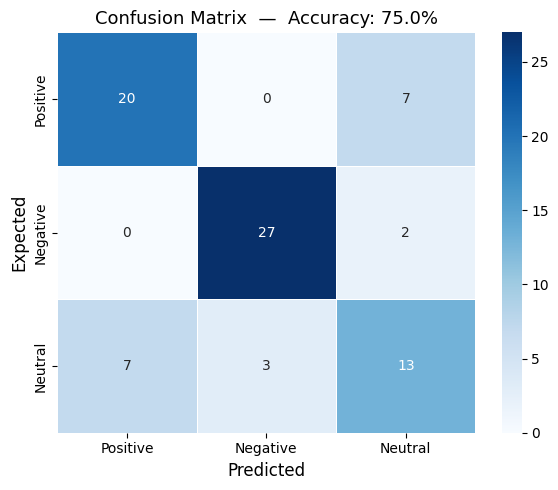

Saved → confusion_matrix.png


In [17]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

results_df = pd.DataFrame(results)
y_true = results_df['expected'].tolist()
y_pred = results_df['predicted'].tolist()

acc       = accuracy_score(y_true, y_pred)
n_correct = results_df['correct'].sum()
n_unknown = (results_df['predicted'] == 'Unknown').sum()

print("=" * 60)
print(f"  Overall Accuracy : {acc:.1%}  ({n_correct}/{len(results_df)} correct)")
print(f"  Unparsed labels  : {n_unknown}")
print("=" * 60)
print()
print(classification_report(
    y_true, y_pred,
    labels=['Positive', 'Negative', 'Neutral'],
    zero_division=0
))

# ── Confusion matrix ──────────────────────────────────────────────────────────
labels = ['Positive', 'Negative', 'Neutral']
cm = confusion_matrix(y_true, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Expected',  fontsize=12)
ax.set_title(f'Confusion Matrix  —  Accuracy: {acc:.1%}', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("Saved → confusion_matrix.png")


## 7 · Misclassified Headlines

In [18]:
wrong_df = results_df[results_df['correct'] == False][
    ['index', 'headline', 'expected', 'predicted', 'reasoning']
].reset_index(drop=True)

print(f"Misclassified: {len(wrong_df)} / {len(results_df)}")
print()
for _, row in wrong_df.iterrows():
    print(f"#{int(row['index']):3d} | Expected={row['expected']:<9s} Predicted={row['predicted']}")
    print(f"       {row['headline'][:110]}")
    print(f"       Reasoning: {row['reasoning'][:120]}")
    print()


Misclassified: 20 / 80

#  1 | Expected=Negative  Predicted=Neutral
       The company's EBITDA dropped 13.7% year-over-year, reflecting subdued pricing and lower volumes.
       Reasoning: 

#  2 | Expected=Neutral   Predicted=Positive
       Finland-based international machinery rental company Ramirent Plc (OMX Helsinki: RMR 1V) reported on Friday (1
       Reasoning: Positive

# 13 | Expected=Negative  Predicted=Neutral
       Sales volumes at Tesco Corporation dropped sharply, contributing to a 20.1% decline in quarterly revenues.
       Reasoning: 

# 16 | Expected=Positive  Predicted=Neutral
       The contract covers HDO platform, AC 800 and CXE 880 optical Fttb nodes designed to increase the forward and r
       Reasoning: Neutral

# 17 | Expected=Neutral   Predicted=Positive
       The alliance aims to tap pocketable mobile computers, netbooks, tablets, mediaphones, connected TVs and in-veh
       Reasoning: The headline describes a positive development in technology.

# 20 | 

## 8 · Save Results

In [19]:
out = '/content/sentiment_results.csv'
results_df[['index','headline','expected','predicted','correct']].to_csv(out, index=False)
print(f"Results saved → {out}")

print("\nLabel distribution comparison:")
comp = pd.DataFrame({
    'Expected' : results_df['expected'].value_counts(),
    'Predicted': results_df['predicted'].value_counts(),
}).fillna(0).astype(int)
print(comp.to_string())


Results saved → /content/sentiment_results.csv

Label distribution comparison:
          Expected  Predicted
Negative        29         30
Neutral         23         22
Positive        28         27
Unknown          0          1
